In [1]:
import pandas as pd

df = pd.read_csv("../data/survey.csv")

df.head()

,Timestamp,Age,Gender,Country,state,self_employed,family_history,treatment,work_interfere,no_employees,...,leave,mental_health_consequence,phys_health_consequence,coworkers,supervisor,mental_health_interview,phys_health_interview,mental_vs_physical,obs_consequence,comments
0,2014-08-27 11:29:31,37,Female,United States,IL,NaN,No,Yes,Often,6-25,...,Somewhat easy,No,No,Some of them,Yes,No,Maybe,Yes,No,NaN
1,2014-08-27 11:29:37,44,M,United States,IN,NaN,No,No,Rarely,More than 1000,...,Don't know,Maybe,No,No,No,No,No,Don't know,No,NaN
2,2014-08-27 11:29:44,32,Male,Canada,NaN,NaN,No,No,Rarely,6-25,...,Somewhat difficult,No,No,Yes,Yes,Yes,Yes,No,No,NaN
3,2014-08-27 11:29:46,31,Male,United Kingdom,NaN,NaN,Yes,Yes,Often,26-100,...,Somewhat difficult,Yes,Yes,Some of them,No,Maybe,Maybe,No,Yes,NaN
4,2014-08-27 11:30:22,31,Male,United States,TX,NaN,No,No,Never,100-500,...,Don't know,No,No,Some of them,Yes,Yes,Yes,Don't know,No,NaN


In [2]:
print(df.shape)

df.info()

(1259, 27)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1259 entries, 0 to 1258
Data columns (total 27 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   Timestamp                  1259 non-null   object
 1   Age                        1259 non-null   int64 
 2   Gender                     1259 non-null   object
 3   Country                    1259 non-null   object
 4   state                      744 non-null    object
 5   self_employed              1241 non-null   object
 6   family_history             1259 non-null   object
 7   treatment                  1259 non-null   object
 8   work_interfere             995 non-null    object
 9   no_employees               1259 non-null   object
 10  remote_work                1259 non-null   object
 11  tech_company               1259 non-null   object
 12  benefits                   1259 non-null   object
 13  care_options               1259 non-null   object
 1

In [3]:
df.columns

Index(['Timestamp', 'Age', 'Gender', 'Country', 'state', 'self_employed',
       'family_history', 'treatment', 'work_interfere', 'no_employees',
       'remote_work', 'tech_company', 'benefits', 'care_options',
       'wellness_program', 'seek_help', 'anonymity', 'leave',
       'mental_health_consequence', 'phys_health_consequence', 'coworkers',
       'supervisor', 'mental_health_interview', 'phys_health_interview',
       'mental_vs_physical', 'obs_consequence', 'comments'],
      dtype='object')

In [4]:
df.isnull().sum()

Timestamp                       0
Age                             0
Gender                          0
Country                         0
state                         515
self_employed                  18
family_history                  0
treatment                       0
work_interfere                264
no_employees                    0
remote_work                     0
tech_company                    0
benefits                        0
care_options                    0
wellness_program                0
seek_help                       0
anonymity                       0
leave                           0
mental_health_consequence       0
phys_health_consequence         0
coworkers                       0
supervisor                      0
mental_health_interview         0
phys_health_interview           0
mental_vs_physical              0
obs_consequence                 0
comments                     1095
dtype: int64

In [5]:
(df.isnull().sum()/len(df))*100

Timestamp                     0.000000
Age                           0.000000
Gender                        0.000000
Country                       0.000000
state                        40.905481
self_employed                 1.429706
family_history                0.000000
treatment                     0.000000
work_interfere               20.969023
no_employees                  0.000000
remote_work                   0.000000
tech_company                  0.000000
benefits                      0.000000
care_options                  0.000000
wellness_program              0.000000
seek_help                     0.000000
anonymity                     0.000000
leave                         0.000000
mental_health_consequence     0.000000
phys_health_consequence       0.000000
coworkers                     0.000000
supervisor                    0.000000
mental_health_interview       0.000000
phys_health_interview         0.000000
mental_vs_physical            0.000000
obs_consequence          

In [6]:
df.duplicated().sum()

0

In [7]:
df["Age"].describe()

count    1.259000e+03
mean     7.942815e+07
std      2.818299e+09
min     -1.726000e+03
25%      2.700000e+01
50%      3.100000e+01
75%      3.600000e+01
max      1.000000e+11
Name: Age, dtype: float64

In [8]:
df["Age"].sort_values().head(20)

715    -1726
143      -29
1127      -1
734        5
989        8
1090      11
282       18
287       18
43        18
482       18
478       18
93        18
118       18
991       19
1027      19
129       19
75        19
150       19
1020      19
749       19
Name: Age, dtype: int64

In [9]:
df["Age"].sort_values().tail(20)

498              54
372              55
964              55
419              55
1186             56
294              56
870              56
631              56
475              57
643              57
466              57
471              58
1236             60
297              60
952              61
520              62
560              65
1182             72
364             329
390     99999999999
Name: Age, dtype: int64

Investigate Gender

In [10]:
df["Gender"].value_counts().head(50)

Gender
Male                                              615
male                                              206
Female                                            121
M                                                 116
female                                             62
F                                                  38
m                                                  34
f                                                  15
Make                                                4
Male                                                3
Woman                                               3
Cis Male                                            2
Man                                                 2
Female (trans)                                      2
Female                                              2
Trans woman                                         1
msle                                                1
male leaning androgynous                            1
Neuter               

Target Variables

In [11]:
df["treatment"].value_counts()

treatment
Yes    637
No     622
Name: count, dtype: int64

Age Column fixing

In [12]:
df = df[(df["Age"] >= 18) & (df["Age"] <= 70)]

In [13]:
print(df.shape)

df["Age"].describe()

(1250, 27)


count    1250.000000
mean       32.044800
std         7.203076
min        18.000000
25%        27.000000
50%        31.000000
75%        36.000000
max        65.000000
Name: Age, dtype: float64

For Gender

In [14]:
def clean_gender(gender):
    gender = str(gender).lower().strip()

    male_keywords = [
        'male','m','man','cis male','cis man',
        'male-ish','mal','mail','maile','guy'
    ]

    female_keywords = [
        'female','f','woman','cis female',
        'femake','femail'
    ]

    if any(word in gender for word in male_keywords):
        return 'Male'

    elif any(word in gender for word in female_keywords):
        return 'Female'

    else:
        return 'Other'

In [15]:
df["Gender"] = df["Gender"].apply(clean_gender)

In [16]:
df["Gender"].value_counts()

Gender
Male      1187
Female      54
Other        9
Name: count, dtype: int64

Handle Missing Values

In [17]:
df["state"] = df["state"].fillna("Unknown")

df["self_employed"] = df["self_employed"].fillna("No")

df["work_interfere"] = df["work_interfere"].fillna("Don't know")

df["comments"] = df["comments"].fillna("")

In [18]:
df.isnull().sum()

Timestamp                    0
Age                          0
Gender                       0
Country                      0
state                        0
self_employed                0
family_history               0
treatment                    0
work_interfere               0
no_employees                 0
remote_work                  0
tech_company                 0
benefits                     0
care_options                 0
wellness_program             0
seek_help                    0
anonymity                    0
leave                        0
mental_health_consequence    0
phys_health_consequence      0
coworkers                    0
supervisor                   0
mental_health_interview      0
phys_health_interview        0
mental_vs_physical           0
obs_consequence              0
comments                     0
dtype: int64

Saving clean dataset now

In [19]:
df.to_csv("../data/cleaned_survey.csv", index=False)

EDA (Exploratory Data Analysis)

In [20]:
import os

os.makedirs("../visuals", exist_ok=True)

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

Age Distribution

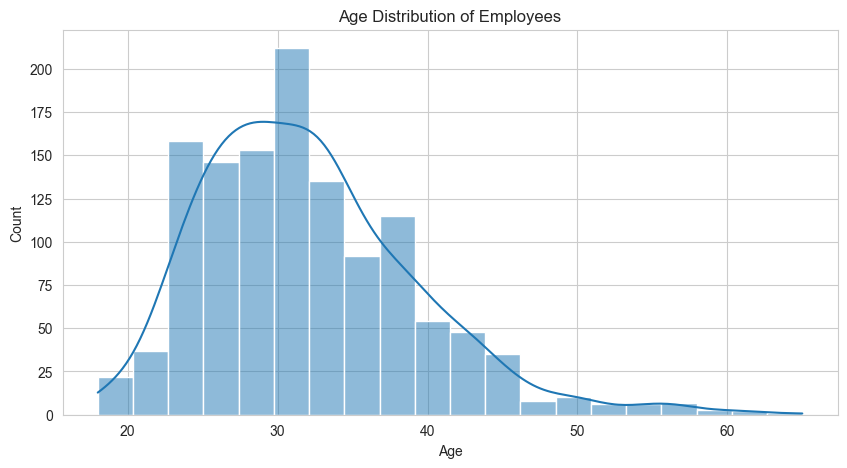

<Figure size 640x480 with 0 Axes>

In [22]:
plt.figure(figsize=(10,5))
sns.histplot(df["Age"], bins=20, kde=True)

plt.title("Age Distribution of Employees")
plt.xlabel("Age")
plt.ylabel("Count")

plt.show()
plt.savefig("../visuals/age_distribution.png")

Most employees fall between 25 and 40 years of age.
The workforce is predominantly young to middle-aged.

Gender Distribution

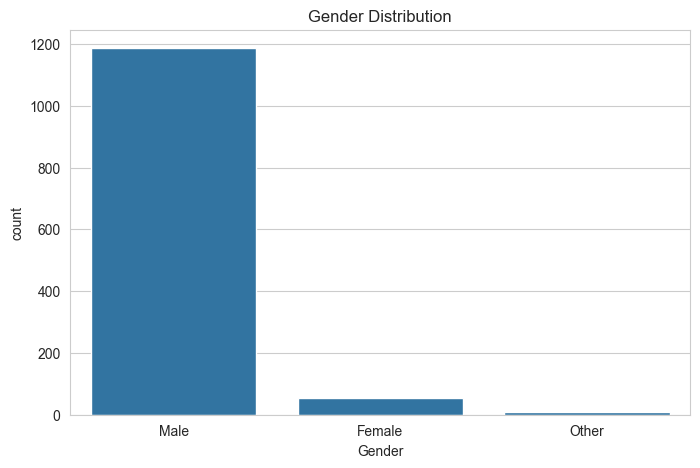

<Figure size 640x480 with 0 Axes>

In [23]:
plt.figure(figsize=(8,5))

sns.countplot(x="Gender", data=df)

plt.title("Gender Distribution")

plt.show()
plt.savefig("../visuals/gender_distribution.png")

Male respondents form the majority of survey participants.
Female and Other categories are comparatively smaller.

Treatment Distribution

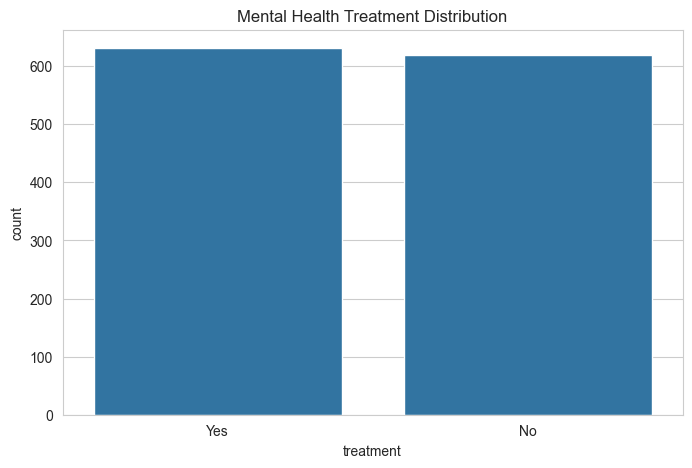

<Figure size 640x480 with 0 Axes>

In [24]:
plt.figure(figsize=(8,5))

sns.countplot(x="treatment", data=df)

plt.title("Mental Health Treatment Distribution")

plt.show()
plt.savefig("../visuals/treatment_distribution.png")

The dataset is well-balanced between employees who sought treatment and those who did not.

Family History vs Treatment

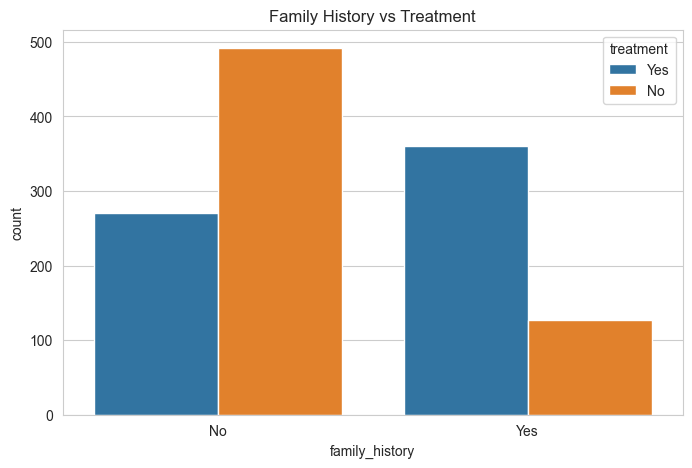

<Figure size 640x480 with 0 Axes>

In [25]:
plt.figure(figsize=(8,5))

sns.countplot(
    x="family_history",
    hue="treatment",
    data=df
)

plt.title("Family History vs Treatment")

plt.show()
plt.savefig("../visuals/family_history_distribution.png")

People with a family history of mental illness are more likely to seek treatment.

Work Interference vs Treatment

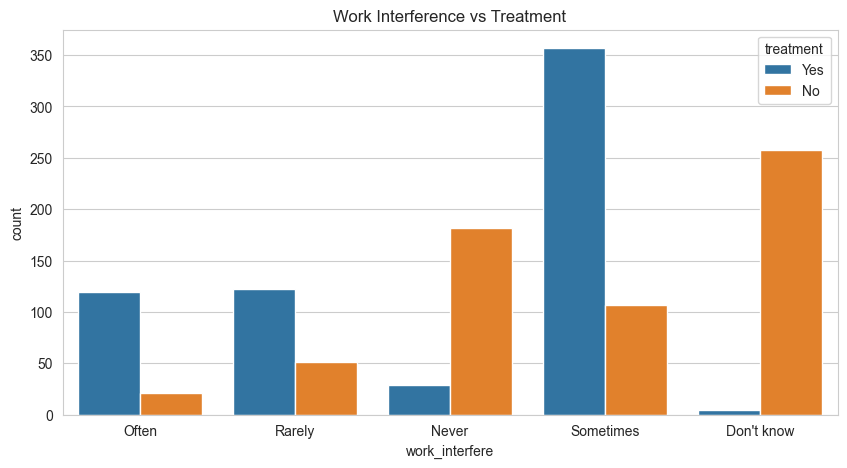

<Figure size 640x480 with 0 Axes>

In [26]:
plt.figure(figsize=(10,5))

sns.countplot(
    x="work_interfere",
    hue="treatment",
    data=df
)

plt.title("Work Interference vs Treatment")

plt.show()
plt.savefig("../visuals/work_interfere_distribution.png")

Employees reporting frequent work interference show higher treatment rates.

Top 10 Countries

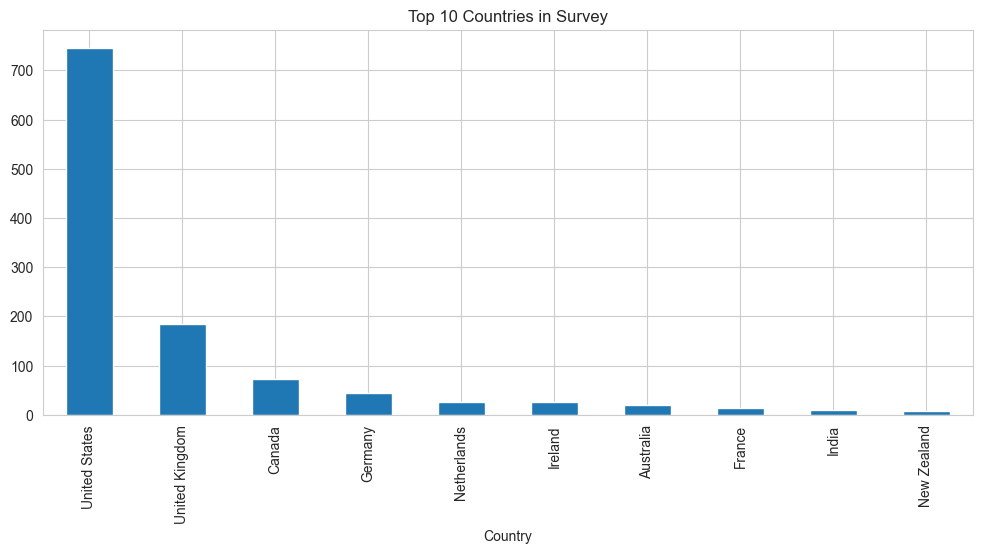

<Figure size 640x480 with 0 Axes>

In [27]:
plt.figure(figsize=(12,5))

df["Country"].value_counts().head(10).plot(kind="bar")

plt.title("Top 10 Countries in Survey")

plt.show()
plt.savefig("../visuals/country_distribution.png")

US dominates survey

In [28]:
df[df["comments"] != ""]["comments"].head(10)

13    I'm not on my company's health insurance which...
15    I have chronic low-level neurological issues t...
16    My company does provide healthcare but not to ...
24                  Relatively new job. Ask again later
25    Sometimes I think  about using drugs for my me...
33    I selected my current employer based on its po...
45    Our health plan has covered my psychotherapy a...
49    I just started a new job last week hence a lot...
59    In addition to my own mental health issues I'v...
66                      Thanks for doing this research.
Name: comments, dtype: object

In [29]:
comments_df = df[df["comments"] != ""].copy()

print(comments_df.shape)

(161, 27)


Import NLP Libraries

In [30]:
import nltk
import re

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

In [31]:
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\Admin\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Admin\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\Admin\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

Preprocesssing func

In [32]:
stop_words = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()

def preprocess_text(text):

    text = str(text).lower()

    text = re.sub(r'[^a-zA-Z\s]', '', text)

    tokens = nltk.word_tokenize(text)

    tokens = [
        lemmatizer.lemmatize(word)
        for word in tokens
        if word not in stop_words
    ]

    return " ".join(tokens)

Cleaning

In [33]:
comments_df["clean_comments"] = comments_df["comments"].apply(preprocess_text)

In [34]:
comments_df[
    ["comments", "clean_comments"]
].head()

,comments,clean_comments
13,I'm not on my company's health insurance which...,im company health insurance could part reason ...
15,I have chronic low-level neurological issues t...,chronic lowlevel neurological issue mental hea...
16,My company does provide healthcare but not to ...,company provide healthcare im fixedterm contra...
24,Relatively new job. Ask again later,relatively new job ask later
25,Sometimes I think about using drugs for my me...,sometimes think using drug mental health issue...


In [35]:
from collections import Counter

all_words = " ".join(
    comments_df["clean_comments"]
).split()

word_freq = Counter(all_words)

word_freq.most_common(20)

[('health', 113),
 ('mental', 101),
 ('issue', 52),
 ('employer', 50),
 ('work', 47),
 ('dont', 44),
 ('would', 34),
 ('company', 33),
 ('people', 30),
 ('im', 28),
 ('know', 27),
 ('question', 21),
 ('depression', 20),
 ('ive', 20),
 ('feel', 19),
 ('get', 19),
 ('insurance', 18),
 ('job', 17),
 ('time', 17),
 ('problem', 16)]

Word cloud genration

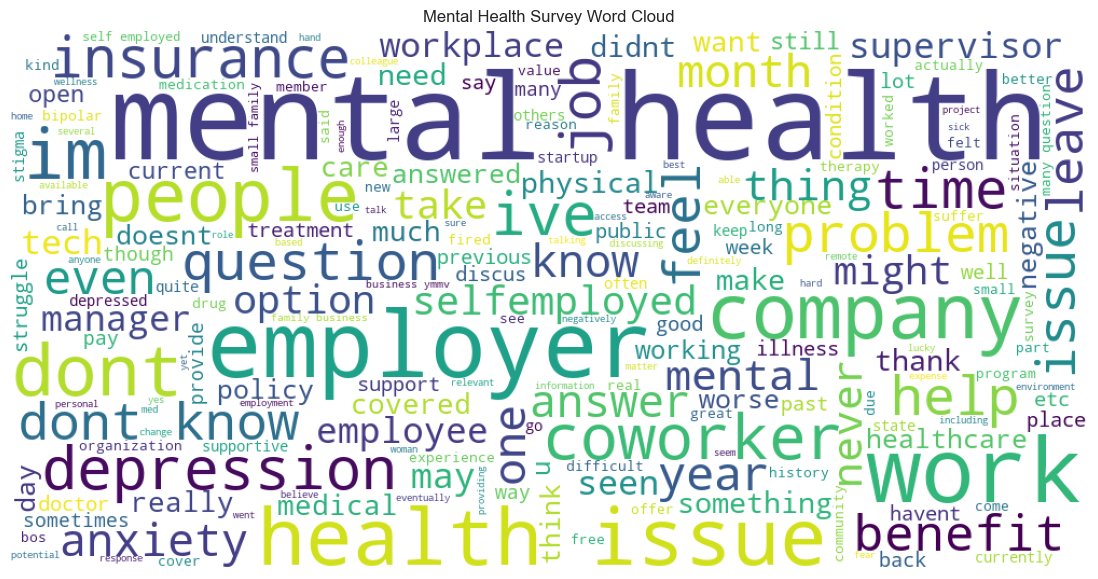

In [36]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color="white"
).generate(" ".join(comments_df["clean_comments"]))

plt.figure(figsize=(15,7))
plt.imshow(wordcloud)
plt.axis("off")
plt.title("Mental Health Survey Word Cloud")
plt.show()
wordcloud.to_file("../visuals/mental_health_wordcloud.png")

ML Part

Create Modeling Dataset

In [37]:
df["treatment"] = df["treatment"].map({
    "No": 0,
    "Yes": 1
})

In [38]:
df_model = df.drop(
    columns=[
        "Timestamp",
        "comments"
    ]
)

In [39]:
df_model = pd.get_dummies(
    df_model,
    drop_first=True
)

In [40]:
print(df_model.shape)

(1250, 136)


Creating X and Y

In [41]:
X = df_model.drop("treatment", axis=1)

y = df_model["treatment"]

Test-train split

In [42]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [43]:
print(X_train.shape)
print(X_test.shape)

(1000, 135)
(250, 135)
